In [2]:
import sys
import os
import yaml
import numpy as np

from loaders.usgs_loader import USGSLoader
from interpolation.usgs_krig import USGSKrig

In [3]:
cfg = "../configs/usgsgaugekrig_50.yaml"
loader = USGSLoader(cfg)
year, month, day, hour = 2024, 9, 27, 4
data = loader.get_streamflow(year, month, day, hour)

[IV] Fetching hour 04 mean (1379 sites)
[IV] 100/1379
[IV] 200/1379
[IV] 300/1379
[IV] 400/1379
[IV] 500/1379
[IV] 600/1379
[IV] 700/1379
[IV] 800/1379
[IV] 900/1379
[IV] 1000/1379
[IV] 1100/1379
[IV] 1200/1379
[IV] 1300/1379
[IV] 1379/1379
2024-09-27_H04: 1319 obs, min=0.0000, max=14.2905, mean=0.4724


In [4]:
krig = USGSKrig(data, cfg, year, month, day)

In [5]:
# Compute kriging first
krig.compute_kriging()

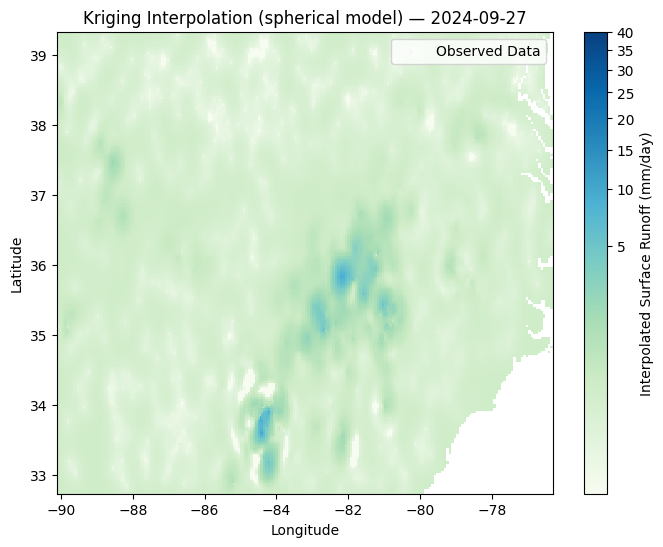

In [6]:
# Generate the kriging interpolation map
krig.map_krig_interpolation()

In [7]:
# Compute semivariance first
krig.compute_semivariogram()

(array([  27.1355375 ,   81.40661249,  135.67768749,  189.94876248,
         244.21983748,  298.49091247,  352.76198747,  407.03306246,
         461.30413746,  515.57521245,  569.84628745,  624.11736244,
         678.38843744,  732.65951243,  786.93058743,  841.20166242,
         895.47273742,  949.74381241, 1004.01488741, 1058.2859624 ,
        1112.5570374 , 1166.82811239, 1221.09918739, 1275.37026238,
        1329.64133738]),
 array([4.29664275e+00, 3.40768658e+00, 2.54288014e+00, 2.54133930e+00,
        3.24627466e+00, 2.82732642e+00, 3.01569159e+00, 2.68481454e+00,
        2.70341826e+00, 3.12697518e+00, 3.11931090e+00, 2.39713782e+00,
        2.04221982e+00, 2.16132523e+00, 1.56557794e+00, 2.18960365e+00,
        2.08100956e+00, 2.61895353e-01, 1.16869276e-01, 7.26648057e-02,
        4.45879393e-02, 6.04171560e-02, 8.56564994e-02, 3.53820712e-02,
        2.47768875e-03]))

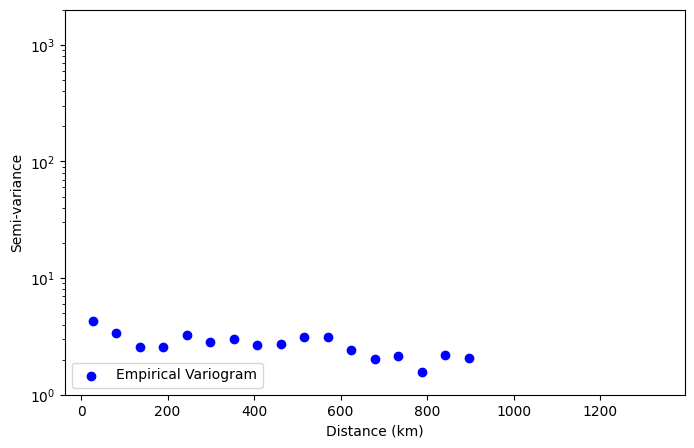

In [8]:
# Plot the variogram
krig.plot_variogram()

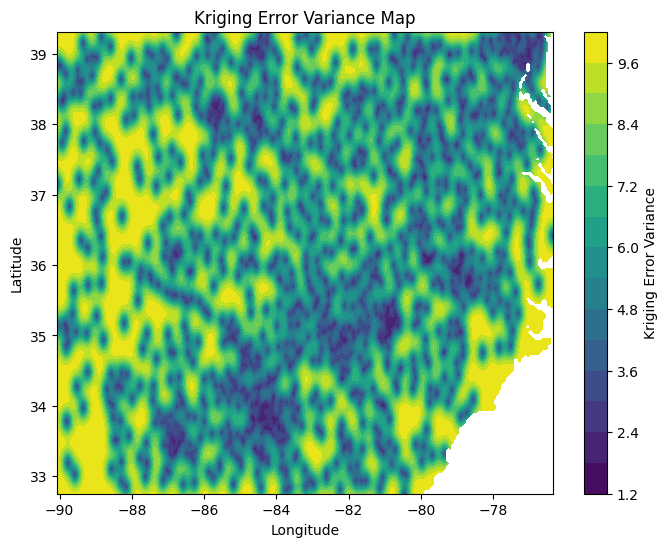

In [9]:
# Generate the kriging error variance map
krig.map_krig_error_variance()

In [10]:
interp_path, vario_path = krig.export_all()
print("data exported to")
print(interp_path)
print(vario_path)

data exported to
/mnt/disk2/temp/interp_2024-09-27.npz
/mnt/disk2/temp/variogram_2024-09-27.csv


In [11]:
z = np.asarray(krig.z_interp)
pos = z[z > 0]
print("pos count:", pos.size, "min:", pos.min(), "max:", pos.max())

pos count: 39824 min: 0.000284215597119625 max: 9.19751760305035


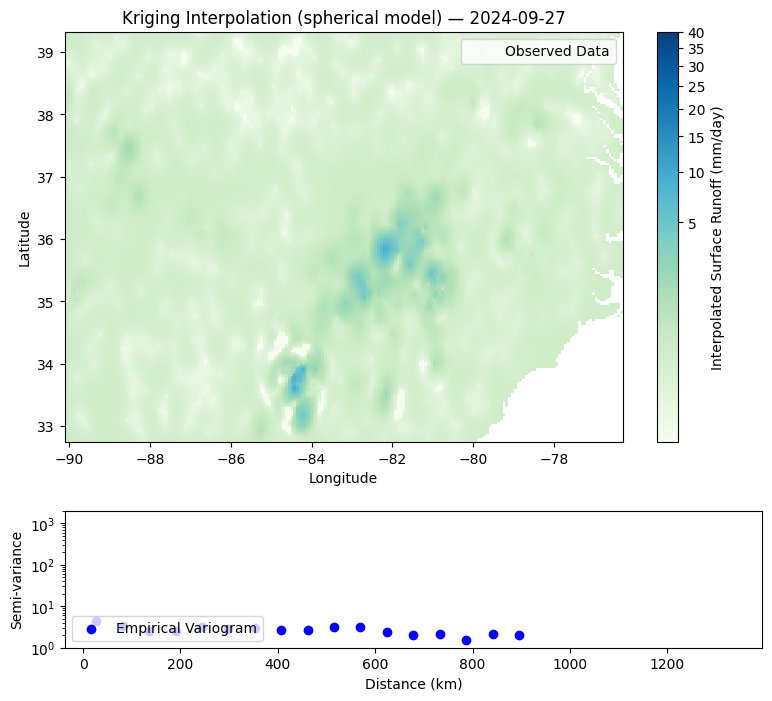

In [12]:
krig.plot_interpolation_with_variogram()